In [7]:
!pip install transformers pandas matplotlib scikit-learn tqdm

In [ ]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from tqdm.auto import tqdm
from transformers import get_linear_schedule_with_warmup

# From Gemini

# use GPU if available in the environment
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load Kaggle data
train_df = pd.read_csv("../data/train.csv")
test_df  = pd.read_csv("../data/test.csv")

# Map labels to 0 and 1
label_map = {"negative": 0, "positive": 1} 
train_df["label_idx"] = train_df["label"].map(label_map)

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df["text"].tolist(), train_df["label_idx"].tolist(), 
    test_size=0.2, random_state=42
)

Using device: cuda


In [9]:
# From Gemini

model_name = "huawei-noah/TinyBERT_General_4L_312D"

tokenizer = BertTokenizer.from_pretrained(model_name)
# num_labels 2 for binary classification
model = BertForSequenceClassification.from_pretrained(model_name, num_labels=2)
model.to(device)

def encode_data(texts, labels=None):
    encodings = tokenizer(texts, truncation=True, padding=True, max_length=512, return_tensors="pt")
    if labels is not None:
        y = torch.tensor(labels).long()
        return TensorDataset(encodings["input_ids"], encodings["attention_mask"], encodings["token_type_ids"], y)
    else:
        return TensorDataset(encodings["input_ids"], encodings["attention_mask"], encodings["token_type_ids"])

train_dataset = encode_data(train_texts, train_labels)
val_dataset   = encode_data(val_texts, val_labels)
test_dataset  = encode_data(test_df["text"].tolist())

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: huawei-noah/TinyBERT_General_4L_312D
Key                                        | Status     | 
-------------------------------------------+------------+-
fit_denses.{0, 1, 2, 3, 4}.weight          | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
fit_denses.{0, 1, 2, 3, 4}.bias            | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not o

In [10]:
# AdamW has faster convergence for low epochs like ours
# Starting with 3e-5 learning rate, adjusted with lr_scheduler
optimizer = AdamW(model.parameters(), lr=3e-5)
epochs = 4
total_steps = len(train_loader) * epochs
scheduler = lr_scheduler(
    optimizer, 
    num_warmup_steps=int(0.1 * total_steps), 
    num_training_steps=total_steps
)

# Status tracking lists
epoch_losses = []
train_accs = []
val_accs = []

print("Starting Training...")
# Core training loop:
for epoch in range(epochs):
    model.train()
    # initializing tracking data per epoch
    total_loss, correct_train, total_train = 0, 0, 0

    # per epoch training
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
    for batch in progress_bar:
        # unpack inputs, mask, labels, and types
        # also moves to GPU for processing
        b_input_ids, b_mask, b_type_ids, b_labels = [b.to(device) for b in batch]
        optimizer.zero_grad()
        outputs = model(input_ids=b_input_ids, attention_mask=b_mask, token_type_ids=b_type_ids, labels=b_labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        scheduler.step()
        # use argmax here due to binary classification (need only one choice)
        preds = torch.argmax(outputs.logits, dim=1)
        # tracking data
        total_loss += loss.item()
        correct_train += (preds == b_labels).sum().item()
        total_train += b_labels.size(0)
        # training progress
        progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})

    # bookkeeping information for graphing
    avg_train_loss = total_loss / len(train_loader)
    train_acc = correct_train / total_train
    
    # Validation step
    model.eval()
    correct_val, total_val = 0, 0
    with torch.no_grad():
        for batch in val_loader:
            # unpack inputs, mask, labels, and types
            # also moves to GPU for processing
            b_input_ids, b_mask, b_type_ids, b_labels = [b.to(device) for b in batch]
            outputs = model(input_ids=b_input_ids, attention_mask=b_mask, token_type_ids=b_type_ids, labels=b_labels)
            # tracking data
            preds = torch.argmax(outputs.logits, dim=1)
            correct_val += (preds == b_labels).sum().item()
            total_val += b_labels.size(0)

    # more tracking
    val_acc = correct_val / total_val
    
    # Store metrics per epoch
    epoch_losses.append(avg_train_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    print(f"Epoch {epoch+1} | Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

Starting Training...


Epoch 1/4:   0%|          | 0/575 [00:00<?, ?it/s]

Epoch 1 | Loss: 0.2377 | Train Acc: 0.9020 | Val Acc: 0.9796


Epoch 2/4:   0%|          | 0/575 [00:00<?, ?it/s]

Epoch 2 | Loss: 0.0461 | Train Acc: 0.9858 | Val Acc: 0.9852


Epoch 3/4:   0%|          | 0/575 [00:00<?, ?it/s]

Epoch 3 | Loss: 0.0251 | Train Acc: 0.9927 | Val Acc: 0.9928


Epoch 4/4:   0%|          | 0/575 [00:00<?, ?it/s]

Epoch 4 | Loss: 0.0123 | Train Acc: 0.9964 | Val Acc: 0.9922


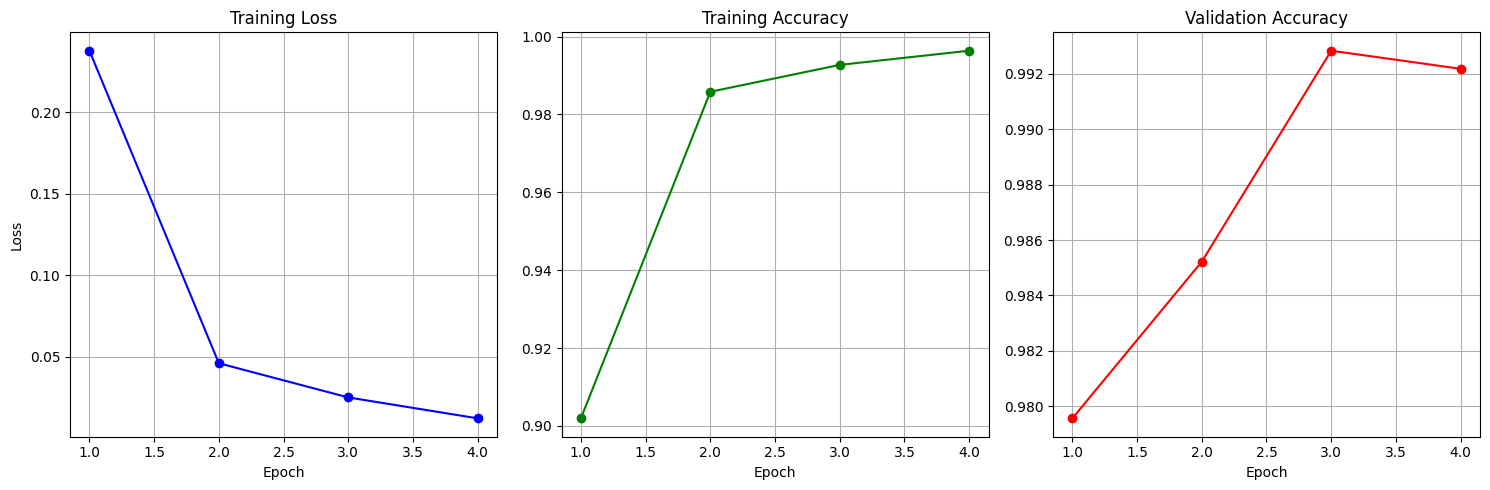

In [11]:
# From Gemini

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(range(1, epochs+1), epoch_losses, marker='o', color='blue')
plt.grid(True)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 3, 2)
plt.plot(range(1, epochs+1), train_accs, marker='o', color='green')
plt.grid(True)
plt.title('Training Accuracy')
plt.xlabel('Epoch')

plt.subplot(1, 3, 3)
plt.plot(range(1, epochs+1), val_accs, marker='o', color='red')
plt.grid(True)
plt.title('Validation Accuracy')
plt.xlabel('Epoch')

plt.tight_layout()
plt.show()

In [ ]:
# From Gemini

print("Generating predictions on test set...")
model.eval()
all_probs = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        b_input_ids, b_mask, b_type_ids = [b.to(device) for b in batch]
        
        outputs = model(input_ids=b_input_ids, attention_mask=b_mask, token_type_ids=b_type_ids)
        
        # Apply Softmax to get probabilities (floats between 0 and 1) for the positive class (Index 1)
        probs = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().numpy()
        all_probs.extend(probs)

# Save formatted submission
submission = pd.DataFrame({
    'Id': test_df['id'],
    'Prob': all_probs
})
submission.to_csv('../outputs/prediction.csv', index=False)
print("Saved prediction.csv successfully!")

Generating predictions on test set...


Testing:   0%|          | 0/727 [00:00<?, ?it/s]

Saved prediction.csv successfully!
